# Step 3: Full Season Price/Attendance Deep Dive
## Headline Goal
Full Season had the highest average price increase of any segment alongside a consistent YoY ticket decline. This notebook tests directly whether price is actually driving that decline, how confident we can be in that relationship, and what it implies for pricing strategy over the next season, including the tradeoffs between recovering attendance and maximizing revenue.

1. Single Game (Weekdays & Sunday) - the dominant driver, gets the most depth
2. **Full Season (price/attendance relationship)** - second-largest
3. Partial Season (what's working/what can we learn) - highest-leverage lever

### - Establish Visualization Standards

In [1]:
# ============================================================
# Imports & Visualization Standards
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

# Standard color palette (order: Blue, Red, Teal, Yellow)
PALETTE = ['#0000a2', '#bc272d', '#50ad9f', '#e9c716']

# Standard figure size for all charts
FIGSIZE = (22, 8.5)

# Axis formatters
def thousands_formatter(x, pos):
    return f'{x/1000:,.0f}K'

def millions_formatter(x, pos):
    return f'${x/1_000_000:,.1f}M'

# Standard label styling
TITLE_STYLE = {'fontsize': 15, 'fontweight': 'bold'}
LABEL_STYLE = {'fontsize': 12, 'fontweight': 'bold'}

# Shared constants used across multiple analysis cells
YEARS = [2021, 2022, 2023]
YEAR_COLORS = dict(zip(YEARS, PALETTE))
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MONTH_ORDER = ['April', 'May', 'June', 'July', 'August', 'September']
DAYNIGHT_ORDER = ['Day Game', 'Night Game']
BAR_WIDTH = 0.25

### - Load in Data

In [2]:
full = pd.read_csv('../step_01_clean_data/clean_data.csv', parse_dates=['Game Date'])

print(f"Loaded: {full.shape[0]} rows, {full.shape[1]} columns")
full.head()

Loaded: 243 rows, 26 columns


,Home Game #,Game Date,Year,Month,Day of Week,Weekend / Weekday,Game Time,Day/Night,Full Season Tickets (#),Full Season Revenue ($),...,Group Avg Price ($),Single Game Tickets (#),Single Game Revenue ($),Single Game Avg Price ($),No-Show Rate,Total Tickets (#),Actual Attendance (#),Total Revenue ($),Average Ticket Price ($),Is First Month
0,1,2021-04-01,2021,April,Thursday,Weekday,13:10:00,Day Game,9361,417794.04,...,46.83,16916,1013906.60,59.94,0.1420,36688,31478,1870492.51,50.98,True
1,2,2021-04-02,2021,April,Friday,Weekend,19:10:00,Night Game,9374,415278.62,...,25.93,9023,272800.32,30.23,0.1752,24520,20224,852818.98,34.78,True
2,3,2021-04-03,2021,April,Saturday,Weekend,18:10:00,Night Game,9398,414149.54,...,30.51,10411,373733.78,35.90,0.1643,28927,24174,1057199.15,36.55,True
3,4,2021-04-04,2021,April,Sunday,Weekend,13:10:00,Day Game,9374,415431.58,...,30.16,12149,411154.96,33.84,0.1609,28561,23966,1057229.43,37.02,True
4,5,2021-04-09,2021,April,Friday,Weekend,19:10:00,Night Game,9376,416211.65,...,30.28,10282,408009.37,39.68,0.1570,29910,25214,1141873.37,38.18,True


In [3]:
fs = full.groupby('Year').agg(
    Total_Tickets=('Full Season Tickets (#)', 'sum'),
    Avg_Price=('Full Season Avg Price ($)', 'mean')
).round(2)

fs['Ticket % Change YoY'] = fs['Total_Tickets'].pct_change() * 100
fs['Price % Change YoY'] = fs['Avg_Price'].pct_change() * 100
fs['Ticket Decline per 1% Price Increase'] = fs['Ticket % Change YoY'] / fs['Price % Change YoY']

print(fs.round(2))

      Total_Tickets  Avg_Price  Ticket % Change YoY  Price % Change YoY  \
Year                                                                      
2021         752350      44.36                  NaN                 NaN   
2022         733496      46.32                -2.51                4.42   
2023         701048      49.72                -4.42                7.34   

      Ticket Decline per 1% Price Increase  
Year                                        
2021                                   NaN  
2022                                 -0.57  
2023                                 -0.60  


**Key Findings:**
- **Full Season shows a consistent price-to-demand relationship.** As the price increase accelerated year over year +4.42% -> +7.34%, the ticket decline accelerated proportionally -2.51% -> -4.42%
- The ratio holds steady both years at roughly -0.57 to -0.60, meaning tickets decline ~0.6% for every 1% price increase. A stable, repeatable pattern with this sample is most likely not a coincidence
- This is one place in the analysis where price genuinely looks like a real driver of the decline, not just a coincidental trend moving alongside it

### - Statistical significance check
The YoY comparison above is based on just 2 data points (2021→2022 and 2022→2023), which isn't enough to confirm a real trend versus coincidence. To properly test whether price is actually driving Full Season's decline, we run a regression using the full game-level dataset (n=243 individual games across all 3 years) and check for statistical significance (p<0.05) rather than relying on a 2-point comparison.

In [4]:
x = full['Full Season Avg Price ($)']
y = full['Full Season Tickets (#)']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Sample size (n): {len(x)} individual games")
print(f"Slope: {slope:.2f} tickets per $1 price increase")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Statistically significant (p<0.05)? {'YES' if p_value < 0.05 else 'NO'}")

Sample size (n): 243 individual games
Slope: -111.35 tickets per $1 price increase
R-squared: 0.5656
P-value: 0.000000
Statistically significant (p<0.05)? YES


**Key Findings:**
- With a real sample size, the price-attendance relationship for Full Season is statistically significant (p<0.0001). This is a genuine, reliable pattern, not something that could be a coincidence
- The slope (-111.35) means each $1 increase in average price is associated with about 111 fewer Full Season tickets sold per game
- R-squared of 0.57 means price alone explains over half the variation in Full Season attendance. The remaining ~43% is driven by other factors we haven't identified
- This confirms what the 2-point YoY comparison suggested, but on much firmer footing. Full Season is a segment in this analysis where we can say with statistical confidence that price is a real driver of the decline, not just something moving alongside it by chance

# Creating a visualization to show the effect of this

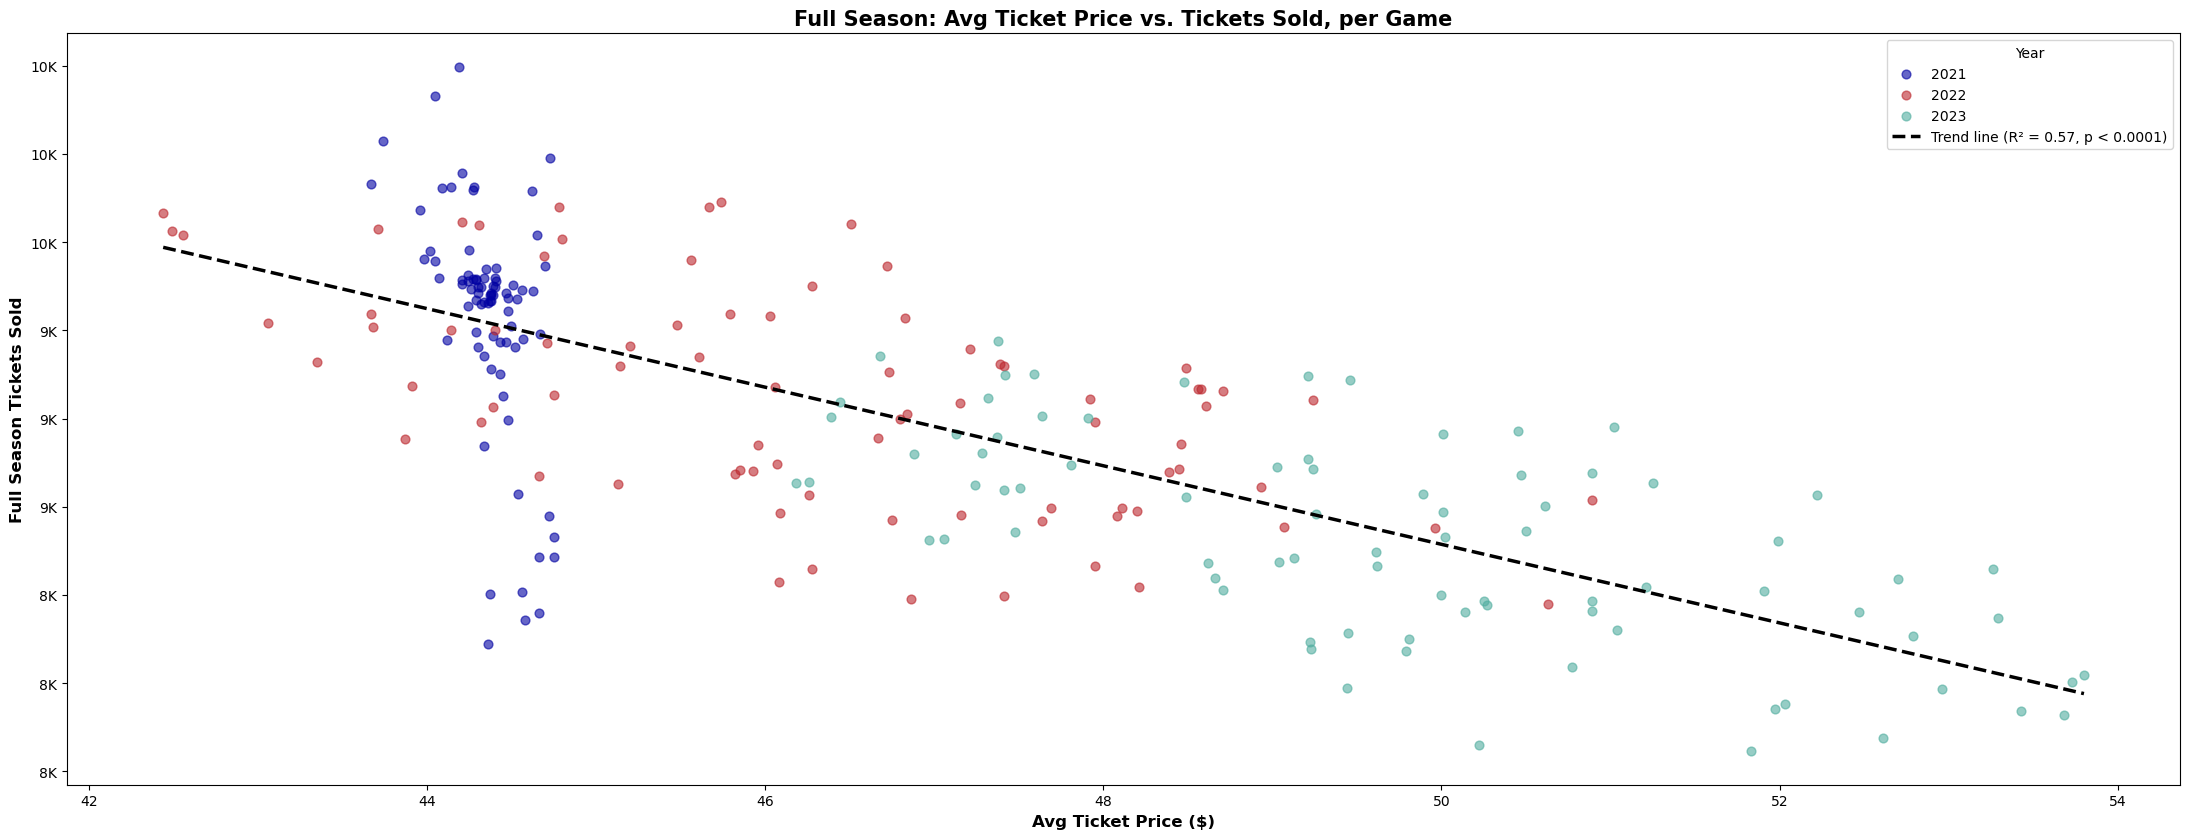

In [5]:
fig, ax = plt.subplots(figsize=FIGSIZE)

# Color points by year for extra context
for year, color in YEAR_COLORS.items():
    mask = full['Year'] == year
    ax.scatter(full.loc[mask, 'Full Season Avg Price ($)'], full.loc[mask, 'Full Season Tickets (#)'],
               color=color, alpha=0.6, s=40, label=str(year))

# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linewidth=2.5, linestyle='dashed',
        label=f'Trend line (R² = {r_value**2:.2f}, p < 0.0001)')

ax.set_title('Full Season: Avg Ticket Price vs. Tickets Sold, per Game', **TITLE_STYLE)
ax.set_xlabel('Avg Ticket Price ($)', **LABEL_STYLE)
ax.set_ylabel('Full Season Tickets Sold', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(title='Year', loc='upper right')

plt.tight_layout()
plt.show()

## Full Season: Is There a True Revenue-Optimal Price, and Where Does It Land?
### - Now that we've confirmed price and attendance are meaningfully correlated, I am curious whether there's an actual mathematical point that maximizes ticket revenue and where that point sits relative to what Acme has actually charged

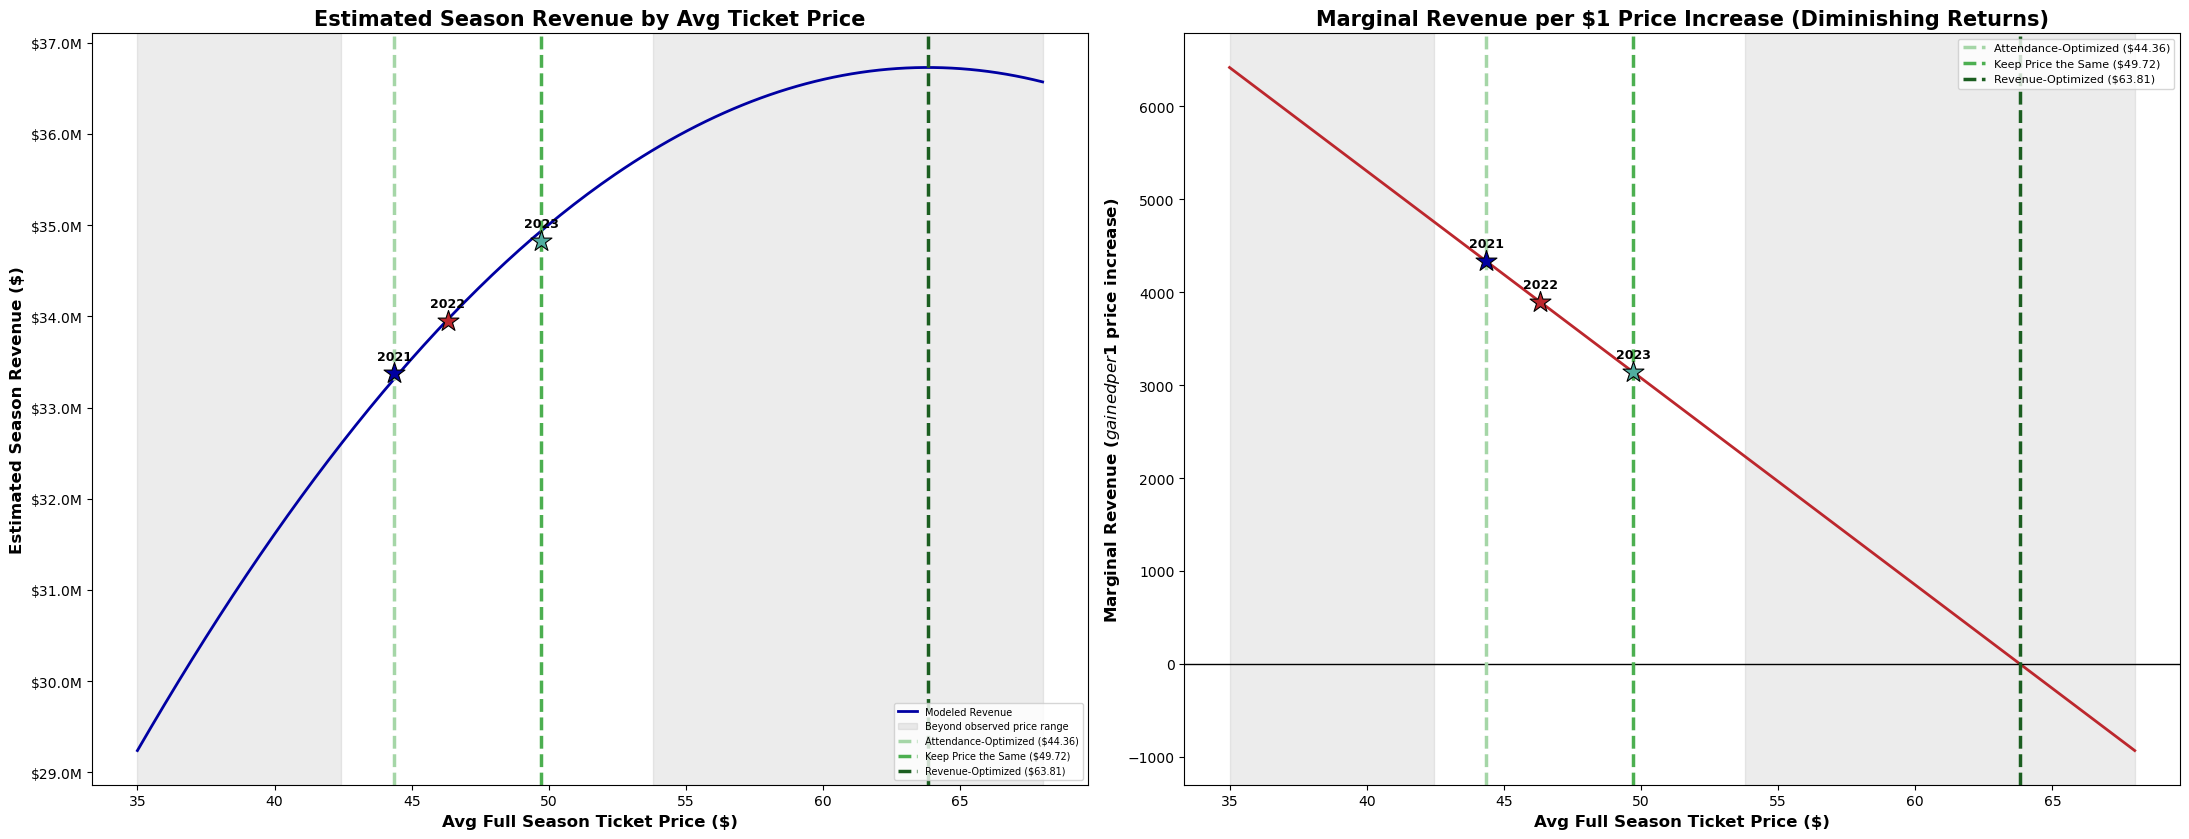

Revenue-Optimized price: $63.81 - marginal revenue crosses zero here (any further increase actually reduces revenue)


In [6]:
games_per_season = 81
observed_max_price = full['Full Season Avg Price ($)'].max()
observed_min_price = full['Full Season Avg Price ($)'].min()

attendance_price = full[full['Year']==2021]['Full Season Avg Price ($)'].mean()
current_price = full[full['Year']==2023]['Full Season Avg Price ($)'].mean()
revenue_optimal_price = -intercept / (2*slope)

option_prices = [attendance_price, current_price, revenue_optimal_price]
option_labels = [
    f'Attendance-Optimized (${attendance_price:.2f})',
    f'Keep Price the Same (${current_price:.2f})',
    f'Revenue-Optimized (${revenue_optimal_price:.2f})'
]
green_shades = ['#a5d6a7', '#4caf50', '#1b5e20']

price_range = np.linspace(35, 68, 200)
revenue_vals = [max(intercept + slope*p, 0) * games_per_season * p for p in price_range]
marginal_slope_vals = [intercept + 2*slope*p for p in price_range]

historical = []
for year in YEARS:
    yr_price = full[full['Year']==year]['Full Season Avg Price ($)'].mean()
    yr_revenue = full[full['Year']==year]['Full Season Revenue ($)'].sum()
    historical.append({'Year': year, 'price': yr_price, 'revenue': yr_revenue})

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# LEFT: Revenue curve
ax = axes[0]
ax.plot(price_range, revenue_vals, linewidth=2, color=PALETTE[0], label='Modeled Revenue')
ax.axvspan(observed_max_price, price_range.max(), color='grey', alpha=0.15, label='Beyond observed price range')
ax.axvspan(price_range.min(), observed_min_price, color='grey', alpha=0.15)
for price, color, label in zip(option_prices, green_shades, option_labels):
    ax.axvline(price, color=color, linestyle='dashed', linewidth=2.5, label=label)
for h in historical:
    ax.scatter(h['price'], h['revenue'], color=YEAR_COLORS[h['Year']], s=250, zorder=5, marker='*', edgecolor='black', linewidth=0.8)
    ax.annotate(str(h['Year']), (h['price'], h['revenue']), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
ax.set_title('Estimated Season Revenue by Avg Ticket Price', **TITLE_STYLE)
ax.set_xlabel('Avg Full Season Ticket Price ($)', **LABEL_STYLE)
ax.set_ylabel('Estimated Season Revenue ($)', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax.legend(fontsize=7, loc='lower right')

# RIGHT: Marginal revenue (diminishing returns), exactly linear
ax2 = axes[1]
ax2.plot(price_range, marginal_slope_vals, linewidth=2, color=PALETTE[1])
ax2.axhline(0, color='black', linewidth=1)
ax2.axvspan(observed_max_price, price_range.max(), color='grey', alpha=0.15)
ax2.axvspan(price_range.min(), observed_min_price, color='grey', alpha=0.15)
for price, color, label in zip(option_prices, green_shades, option_labels):
    ax2.axvline(price, color=color, linestyle='dashed', linewidth=2.5, label=label)
for h in historical:
    yr_marginal = intercept + 2*slope*h['price']
    ax2.scatter(h['price'], yr_marginal, color=YEAR_COLORS[h['Year']], s=250, zorder=5, marker='*', edgecolor='black', linewidth=0.8)
    ax2.annotate(str(h['Year']), (h['price'], yr_marginal), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Marginal Revenue per $1 Price Increase (Diminishing Returns)', **TITLE_STYLE)
ax2.set_xlabel('Avg Full Season Ticket Price ($)', **LABEL_STYLE)
ax2.set_ylabel('Marginal Revenue ($ gained per $1 price increase)', **LABEL_STYLE)
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Revenue-Optimized price: ${revenue_optimal_price:.2f} - marginal revenue crosses zero here (any further increase actually reduces revenue)")

**Key Findings:**
- There is a true revenue-maximizing price, and it lands at $63.81, which is a large increase of about 28% from where Acme is today. This is the opposite direction of what we're trying to accomplish here. 
- Reducing price back to 2021 levels, or simply keeping price where it is now, both still capture the large majority of the total value on the table. Neither is a meaningfully worse choice than chasing the pure revenue-optimal price, and both come with real attendance upside the pure math ignores

**Additional Notes:**
- This view only accounts for ticket revenue. Worth layering in concessions spend per fan to see how that shifts the picture because more fans in the building could offset some of the ticket revenue given up by a lower price
- 20 dollars per fan feels like a reasonable, grounded starting assumption: roughly 10 dollars for a hot dog, 5 dollars for a drink, and 5 dollars for something like peanuts, Cracker Jacks, or popcorn

## Full Season: Bringing Concessions Into the Picture
### - Layering in an assumed $20/fan concessions spend to see whether it changes which option looks best, now that we're weighing attendance recovery against pure ticket revenue

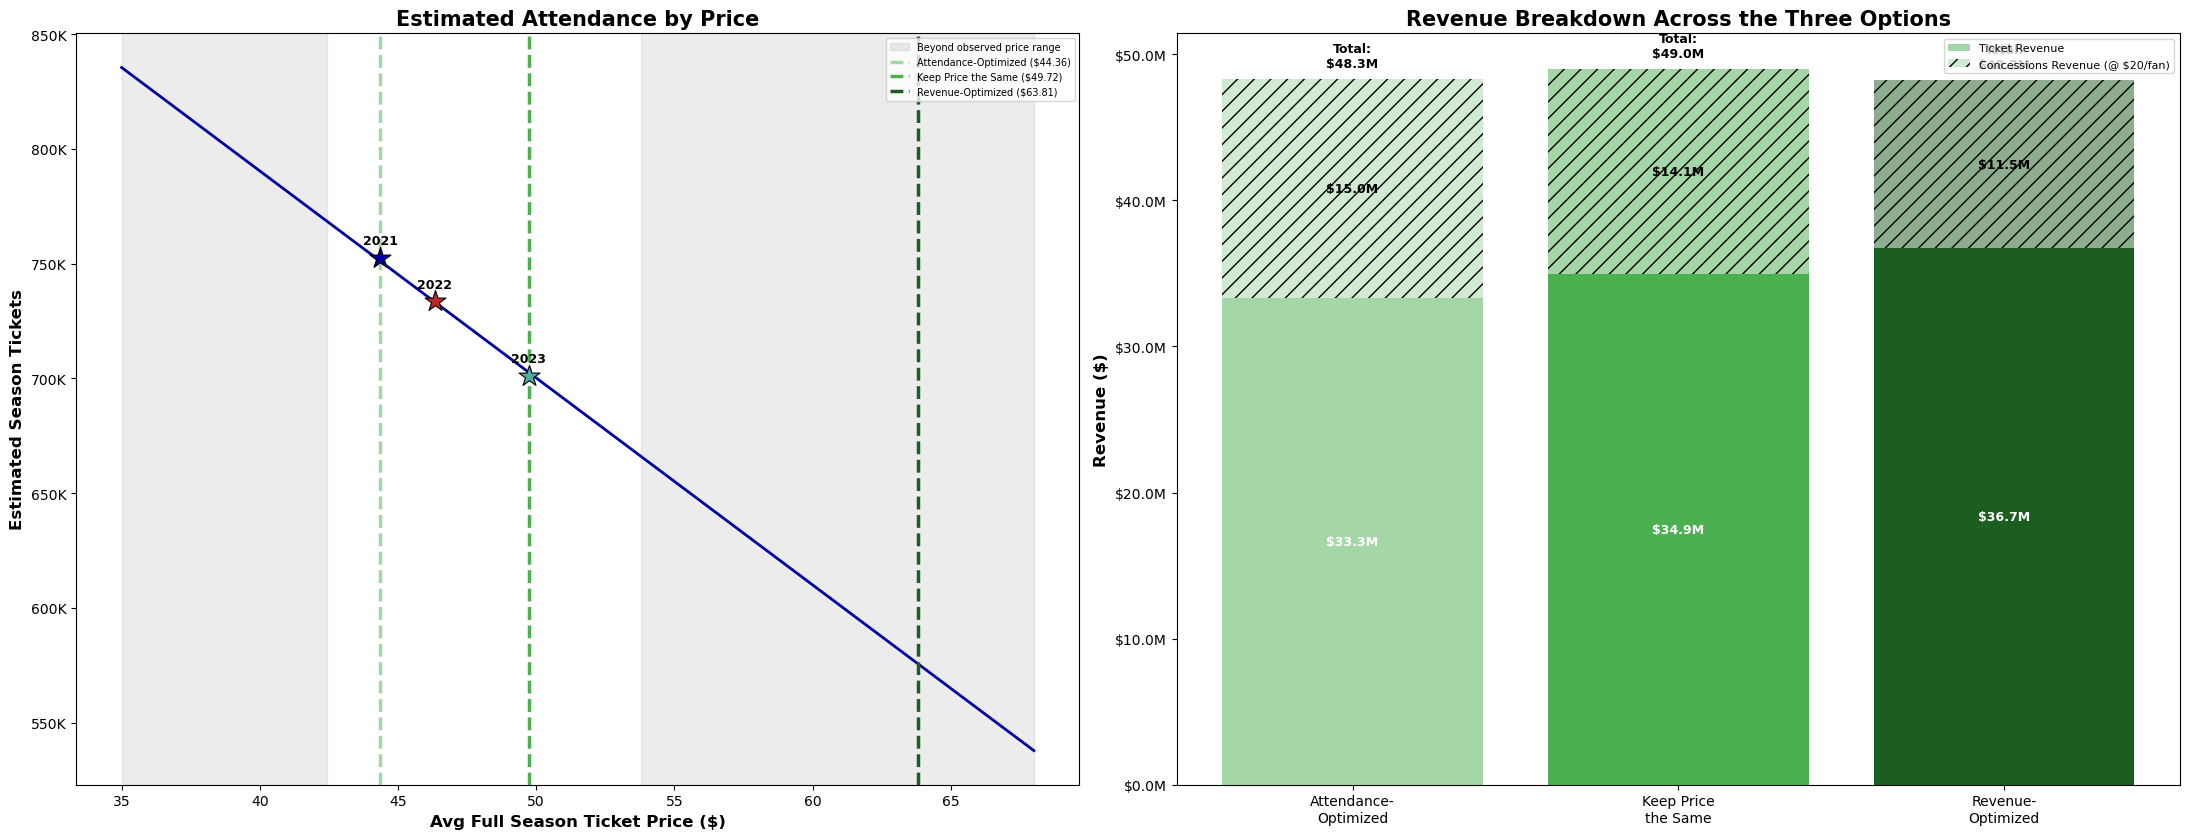

              Option  Price Tickets Ticket Revenue Concessions Revenue Total Value
Attendance-Optimized $44.36 750,967    $33,315,195         $15,019,332 $48,334,527
 Keep Price the Same $49.72 702,629    $34,936,544         $14,052,583 $48,989,128
   Revenue-Optimized $63.81 575,539    $36,727,427         $11,510,775 $48,238,201


In [7]:
games_per_season = 81
C = 20  # assumed concessions spend per fan per game
observed_max_price = full['Full Season Avg Price ($)'].max()
observed_min_price = full['Full Season Avg Price ($)'].min()

attendance_price = full[full['Year']==2021]['Full Season Avg Price ($)'].mean()
current_price = full[full['Year']==2023]['Full Season Avg Price ($)'].mean()
revenue_optimal_price = -intercept / (2*slope)

option_prices = [attendance_price, current_price, revenue_optimal_price]
option_names = ['Attendance-\nOptimized', 'Keep Price\nthe Same', 'Revenue-\nOptimized']
green_shades = ['#a5d6a7', '#4caf50', '#1b5e20']

price_range = np.linspace(35, 68, 150)
tickets_curve = [max(intercept + slope*p, 0) * games_per_season for p in price_range]

historical = []
for year in YEARS:
    yr_price = full[full['Year']==year]['Full Season Avg Price ($)'].mean()
    yr_tickets = full[full['Year']==year]['Full Season Tickets (#)'].sum()
    historical.append({'Year': year, 'price': yr_price, 'tickets': yr_tickets})

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# LEFT: Attendance curve with all three options marked + historical stars
ax = axes[0]
ax.plot(price_range, tickets_curve, linewidth=2, color=PALETTE[0])
ax.axvspan(observed_max_price, price_range.max(), color='grey', alpha=0.15, label='Beyond observed price range')
ax.axvspan(price_range.min(), observed_min_price, color='grey', alpha=0.15)
for price, color, name in zip(option_prices, green_shades, ['Attendance-Optimized', 'Keep Price the Same', 'Revenue-Optimized']):
    ax.axvline(price, color=color, linestyle='dashed', linewidth=2.5, label=f'{name} (${price:.2f})')
for h in historical:
    ax.scatter(h['price'], h['tickets'], color=YEAR_COLORS[h['Year']], s=250, zorder=5, marker='*', edgecolor='black', linewidth=0.8)
    ax.annotate(str(h['Year']), (h['price'], h['tickets']), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
ax.set_title('Estimated Attendance by Price', **TITLE_STYLE)
ax.set_xlabel('Avg Full Season Ticket Price ($)', **LABEL_STYLE)
ax.set_ylabel('Estimated Season Tickets', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(fontsize=7, loc='upper right')

# RIGHT: Revenue breakdown for all three options (ticket + concessions)
ax2 = axes[1]
ticket_revs, concessions_revs = [], []
for price in option_prices:
    tix = max(intercept + slope*price, 0) * games_per_season
    ticket_revs.append(tix * price)
    concessions_revs.append(tix * C)

ax2.bar(option_names, ticket_revs, color=green_shades, label='Ticket Revenue')
ax2.bar(option_names, concessions_revs, bottom=ticket_revs, color=green_shades, alpha=0.5, label=f'Concessions Revenue (@ ${C}/fan)', hatch='//')
for i, (t, c) in enumerate(zip(ticket_revs, concessions_revs)):
    ax2.text(i, t/2, f'${t/1e6:.1f}M', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax2.text(i, t+c/2, f'${c/1e6:.1f}M', ha='center', va='center', fontsize=9, fontweight='bold')
    ax2.text(i, t+c+800000, f'Total:\n${(t+c)/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Revenue Breakdown Across the Three Options', **TITLE_STYLE)
ax2.set_ylabel('Revenue ($)', **LABEL_STYLE)
ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    'Option': ['Attendance-Optimized', 'Keep Price the Same', 'Revenue-Optimized'],
    'Price': [f'${p:.2f}' for p in option_prices],
    'Tickets': [f'{max(intercept+slope*p,0)*games_per_season:,.0f}' for p in option_prices],
    'Ticket Revenue': [f'${r:,.0f}' for r in ticket_revs],
    'Concessions Revenue': [f'${r:,.0f}' for r in concessions_revs],
    'Total Value': [f'${t+c:,.0f}' for t,c in zip(ticket_revs, concessions_revs)]
})
print(summary_df.to_string(index=False))

**Key Findings:**
- Treating "Keep Price the Same" as the control condition shows something important: it actually produces the HIGHEST total value ($48.99M) of all three options once concessions are counted
- This suggests 2023's pricing may already be close to a genuinely well-balanced point - both moving toward more attendance and moving toward more revenue trade away some total value from where Acme already sits
- Attendance-Optimized still meaningfully recovers fans ~50K more tickets than the control

**Additional Notes:**
- **Worth noting that keeping the price the same could also serve as a test to understand other potential impacts of decreasing attendance**

## Full Season: Final Thoughts & Recommendation
Rather than moving the Full Season price up or down, we recommend holding the price flat at 2023 levels for another season and using that as a deliberate test. Keeping prices stable assumes that we will not see a decrease in tickets solely based on price. This removes price as a variable, letting Acme observe whether attendance stabilizes, recovers, or keeps declining and can point to other factors driving the trend next.

- Full Season is the one segment where our data shows a real, statistically significant link between price and attendance
- Holding price flat isolates that relationship. If attendance holds steady or improves next season with no price change, that's a strong signal something other than price is an additional driver
- This approach avoids the risk of committing to an aggressive price change (in either direction) based on a model extrapolated from just 3 years of data
- A full price-optimization exercise that includes real concessions numbers remains a good next step once more seasons of data are available, or if Acme can supply real concessions data now

- **Key assumption:** holding price constant offsets the year-over-year ticket declines we've observed.